In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qls
from molecules import CaOH
%matplotlib inline

Text(0, 0.5, 'Excitation probability')

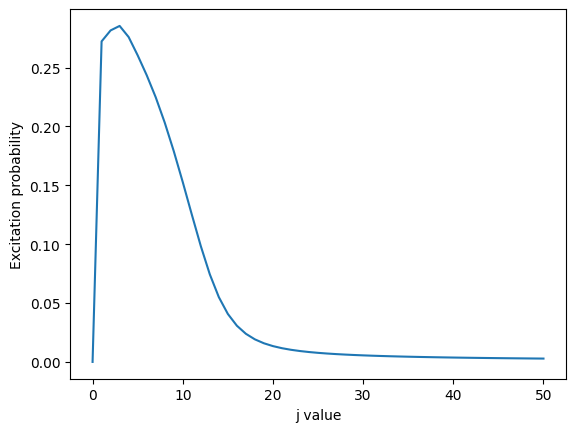

In [13]:
b_field_gauss = 5.0
j_max = 50
temperature = 300
mo = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
states = qls.States(mo, temperature)

duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*0.01
dephased = True
is_minus = True

# Frequencies of target distributions at different Js
signature_transitions = np.array([mo.transition_df.loc[mo.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo.j_max+1)])

j_exc_probs = np.zeros(j_max+1)
for j in range(j_max+1):
    if j == 0:
        continue
    
    # Fissato J, prendo la freq della target distribution e calcolo la exc_prob su tutto il database a quella freq del fascio.
    exc_probs = qls.get_excitation_probabilities(mo, signature_transitions[j], duration_us, rabi_rate_mhz, dephased, is_minus)
    # len(exc_probs) = len(mo.state_df)
    
    # per tutte le righe nel dataframe che hanno J=j, aggiungo la exc_prob corrispondente 
    for i in range(len(exc_probs)):
        if states.j[i] == j:
            j_exc_probs[j] += exc_probs[i]/ (2*(2*j+1))

plt.plot(np.arange(j_max+1), j_exc_probs)
plt.xlabel("j value")
plt.ylabel("Excitation probability")


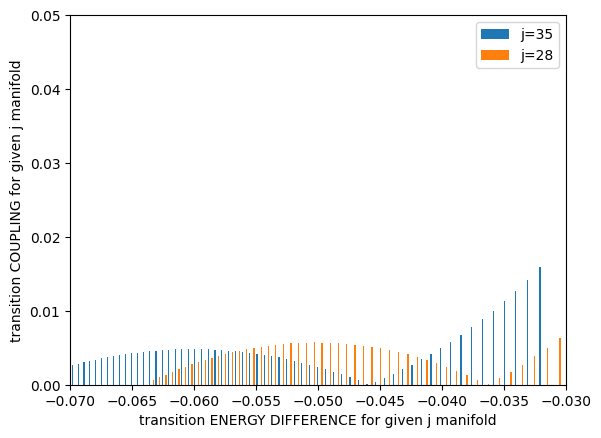

In [15]:
j = 35
# prendo le transizioni di j=35 manifold, e prendo le energy diff
transition_energies = mo.transition_df.loc[mo.transition_df["j"]==j]["energy_diff"].to_numpy(dtype=float)*1e-3

# prendo le transizioni di j=35 manifold, e prendo le energy coupling
transition_couplings = np.abs(mo.transition_df.loc[mo.transition_df["j"]==j]["coupling"].to_numpy(dtype=float))

plt.bar(transition_energies, transition_couplings, width=0.0001, label="j=35")

# Stessa roba con j=28
j2 = 28
transition_energies = mo.transition_df.loc[mo.transition_df["j"]==j2]["energy_diff"].to_numpy(dtype=float)*1e-3
transition_couplings = np.abs(mo.transition_df.loc[mo.transition_df["j"]==j2]["coupling"].to_numpy(dtype=float))

plt.bar(transition_energies, transition_couplings, width=0.0001, label ="j=28")

plt.xlim(-0.07, -0.03)
plt.ylim(0, 0.05)
plt.xlabel("transition ENERGY DIFFERENCE for given j manifold")
plt.ylabel("transition COUPLING for given j manifold")
plt.legend()

[ 0.0085155  -0.01388842 -0.00412072 -0.00272694 -0.00250991 -0.00278616
 -0.00341388 -0.00431972 -0.00542363 -0.00665519 -0.00796628 -0.00932753
 -0.01072148 -0.01213753 -0.01356906 -0.01501179 -0.01646284 -0.01792023
 -0.01938254 -0.02084876 -0.02231812 -0.02379004 -0.02526407 -0.02673988
 -0.02821717 -0.02969574 -0.03117539 -0.03265598 -0.0341374  -0.03561953
 -0.03710229 -0.03858561 -0.04006942 -0.04155368 -0.04303834 -0.04452335
 -0.04600868 -0.04749431 -0.04898021 -0.05046634 -0.0519527  -0.05343926
 -0.05492601 -0.05641293 -0.05790001 -0.05938723 -0.06087459 -0.06236208
 -0.06384968 -0.0653374  -0.06682521]
16
-0.01646283889161713


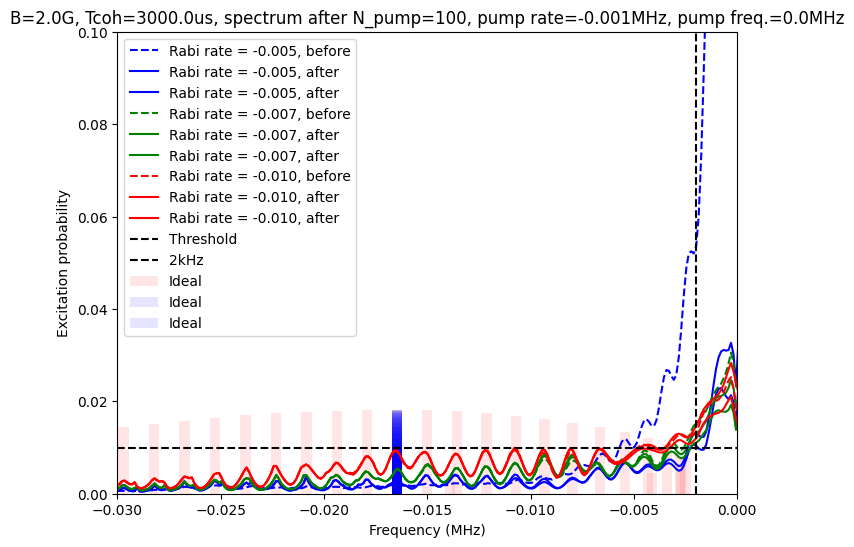

In [34]:
# A) VEDERE APPUNTI PER SPIEGAZIONE


import pandas as pd
#data
b_field_gauss = 2.0
j_max = 50
duration_us = 1000.0
colors = ["blue", "green", "red"]
max_frequency_mhz = 0.03
scan_points = 500
dephased = True
coherence_time_us = 3000.0
is_minus = True
temperature = 300

rabi_rate_mhz_1 = - 2*np.pi*np.array([0.005, 0.007, 0.01])
q1 = qls.Polarization(1, 0, 0)
q2 = qls.Polarization(0, 1, 0)

# pumping data
pump_frequency_mhz = 0.000
num_pumps = 100
pump_rabi_rate_mhz = -0.016469689575617417
pump_duration_us = 1000.0

# Faccio sto passaggio solo per calcolarmi i giusti signature_transitions FINALI (credo)
mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
states1 = qls.States(mo1, temperature)
ac_stark_shifts = qls.get_ac_stark_shifts(mo1, pump_rabi_rate_mhz, pump_rabi_rate_mhz*2., q1, q2)
mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
mo1.transition_df = pd.DataFrame()
mo1.init_transition_dataframe()
signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])

# mo1.plot_zeeman_levels(j_max)
print(signature_transitions)

j_peak = np.argmax(states1.j_distribution())
print(j_peak)

print(signature_transitions[j_peak])



# CASO 1) molecola sotto azione di due laser rabi1 e rabi2. 
#   - molecola inizializzata e temperatura fissa state.dist
#   - molecola sotto azione di due laser rabi1 e rabi2
#   - AC calcolata --> Modifica state_df
#   - states.dist rimane invariato. (domanda: come mai get_spectrum funziona se state1.dist è invariato? thanks to the AC, the transition_df pd has changed. so transition_df <-- get_excitation_probabilities <-- get_spectrum.)
#
fig, ax = plt.subplots(figsize=(8, 6))
for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    # print("1 state_df= ", mo1.state_df)
    # print("1 state.dist = ", states1.dist)

    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)

    # print("2 state_df = ", mo1.state_df)
    # print("2 state.dist = ", states1.dist)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, before", linestyle="--", color=color)


# CASO 2) molecola sotto azione prima del laser di pumping, poi dei due laser rabi1 e rabi2. 
#   - pumping: states1.dist viene modificato. (fino a qui state_df è uguale a  "1 state_df")
#   - successivamente, molecola sotto azione di due laser rabi1 e rabi2
#   - AC calcolata --> Modifica state_df (con rabi1 e rabi2)
#   - states.dist rimane invariato, ossia rimane quello dopo il pumping. (domanda: come mai get_spectrum funziona se state1.dist è invariato? thanks to the AC, the transition_df pd has changed. so transition_df <-- get_excitation_probabilities <-- get_spectrum.)
#
    # print("2 state_df = ", mo1.state_df)
    # print("2 state.dist = ", states1.dist)
    for _ in range(num_pumps):
        states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, coherence_time_us, is_minus).dot(states1.dist)
    # print("2_bis state_df = ", mo1.state_df)
    # print("2_bis state.dist = ", states1.dist)

# for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    # print("3 state_df = ", mo1.state_df)
    # print("3 state.dist = ", states1.dist)
    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    # print("4 state_df = ", mo1.state_df)
    # print("4 state.dist = ", states1.dist)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, after", color=color)

    pump_rabi_rate_mhz = - 0.00932753
    for _ in range(num_pumps):
        states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, coherence_time_us, is_minus).dot(states1.dist)
    # print("2_bis state_df = ", mo1.state_df)
    # print("2_bis state.dist = ", states1.dist)

# for r, color in zip(rabi_rate_mhz_1, colors):
    mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)
    # print("3 state_df = ", mo1.state_df)
    # print("3 state.dist = ", states1.dist)
    ac_stark_shifts = qls.get_ac_stark_shifts(mo1, r, r*2., q1, q2)
    mo1.state_df["zeeman_energy_khz"] += ac_stark_shifts * 1e3
    mo1.transition_df = pd.DataFrame()
    mo1.init_transition_dataframe()
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, coherence_time_us, is_minus)
    # print("4 state_df = ", mo1.state_df)
    # print("4 state.dist = ", states1.dist)
    plt.plot(frequencies, exc_probs1_after, label=f"Rabi rate = {r/(2*np.pi):.3f}, after", color=color)


ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label="Ideal")
ax.bar(signature_transitions[j_peak], states1.j_distribution()*0.5, color="blue", width=0.0005, alpha=0.1, label="Ideal")
ax.bar(signature_transitions[0], states1.j_distribution()*0.5, color="blue", width=0.0005, alpha=0.1, label="Ideal")

ax.hlines(0.01, -max_frequency_mhz, max_frequency_mhz, color="black", linestyle="--", label="Threshold")
ax.vlines(-0.002, 0, 0.1, color="black", linestyle="--", label="2kHz")
ax.legend()
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, Tcoh={coherence_time_us}us, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, 0])
ax.set_ylim([0, 0.1])
plt.show()

-0.016474383145676667


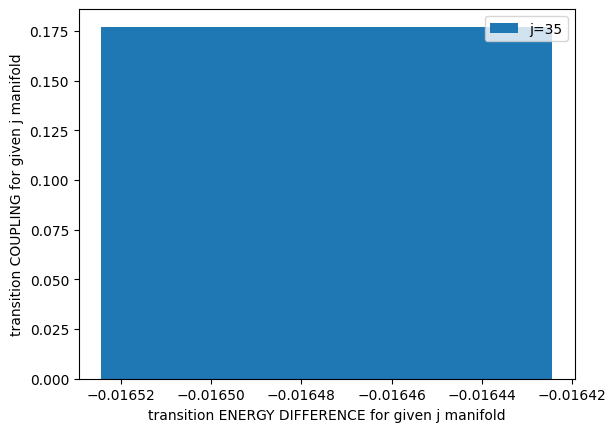

In [26]:
j = 16
# prendo le transizioni di j=35 manifold, e prendo le energy diff
transition_energies = mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"]*1e-3
print(transition_energies)

# prendo le transizioni di j=35 manifold, e prendo le energy coupling
transition_couplings = np.abs(mo1.transition_df.loc[mo1.transition_df["j"]==j]["coupling"].to_numpy(dtype=float))

plt.bar(transition_energies, transition_couplings, width=0.0001, label="j=35")

# plt.xlim(-0.07, -0.03)
# plt.ylim(0, 0.05)
plt.xlabel("transition ENERGY DIFFERENCE for given j manifold")
plt.ylabel("transition COUPLING for given j manifold")
plt.legend()